## To use the Functional API, follow these steps:
Example 1: Simple Linear Model using Functional API

Step 1: Import the Model class

In [10]:

from keras.models import Model

Step 2: Import layers



In [11]:
from keras.layers import Input, Dense, Flatten, Concatenate
# (import whatever layers you need)

Step 3: Define the Input layer

In [12]:
# Define the input layer (3 features)
input_layer = Input(shape=(3,), name='input_layer')

Step 4: Build the network by connecting layers

In [13]:
# Hidden layer with 64 neurons
hidden1 = Dense(64, activation='relu', name='hidden1')(input_layer) # Dense(...)(previous_layer)

# Hidden layer with 32 neurons
hidden2 = Dense(32, activation='relu', name='hidden2')(hidden1)

# Output layer (1 neuron for regression)
output_layer = Dense(1, activation='linear', name='output')(hidden2)

Notice the syntax: Dense(...)(previous_layer) – the layer is called as a function on the previous layer.

Step 5: Create the model

In [14]:
model = Model(inputs=input_layer, outputs=output_layer)

Step 6: Compile and train as usual

In [15]:
"""
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10)
"""

"\nmodel.compile(optimizer='adam', loss='mse')\nmodel.fit(X_train, y_train, epochs=10)\n"

**Explanation:**
- `Input(shape=(3,))` defines the input shape (3 features)
- Each `Dense` layer is called with the previous layer as an argument
- `Model(inputs=..., outputs=...)` ties everything together
- This model is functionally equivalent to a Sequential model, but written in the Functional style

## Checking

In [16]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,369 (9.25 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 0 (0.00 B)

**Step-by-step explanation of the output:**
1. **InputLayer** – Takes input of shape (3,). "None" means batch size is flexible.
2. **hidden1** – Dense layer with 64 neurons. Parameters = 3×64 + 64 = 256.
3. **hidden2** – Dense layer with 32 neurons. Parameters = 64×32 + 32 = 2080.
4. **output** – Dense layer with 1 neuron. Parameters = 32×1 + 1 = 33.

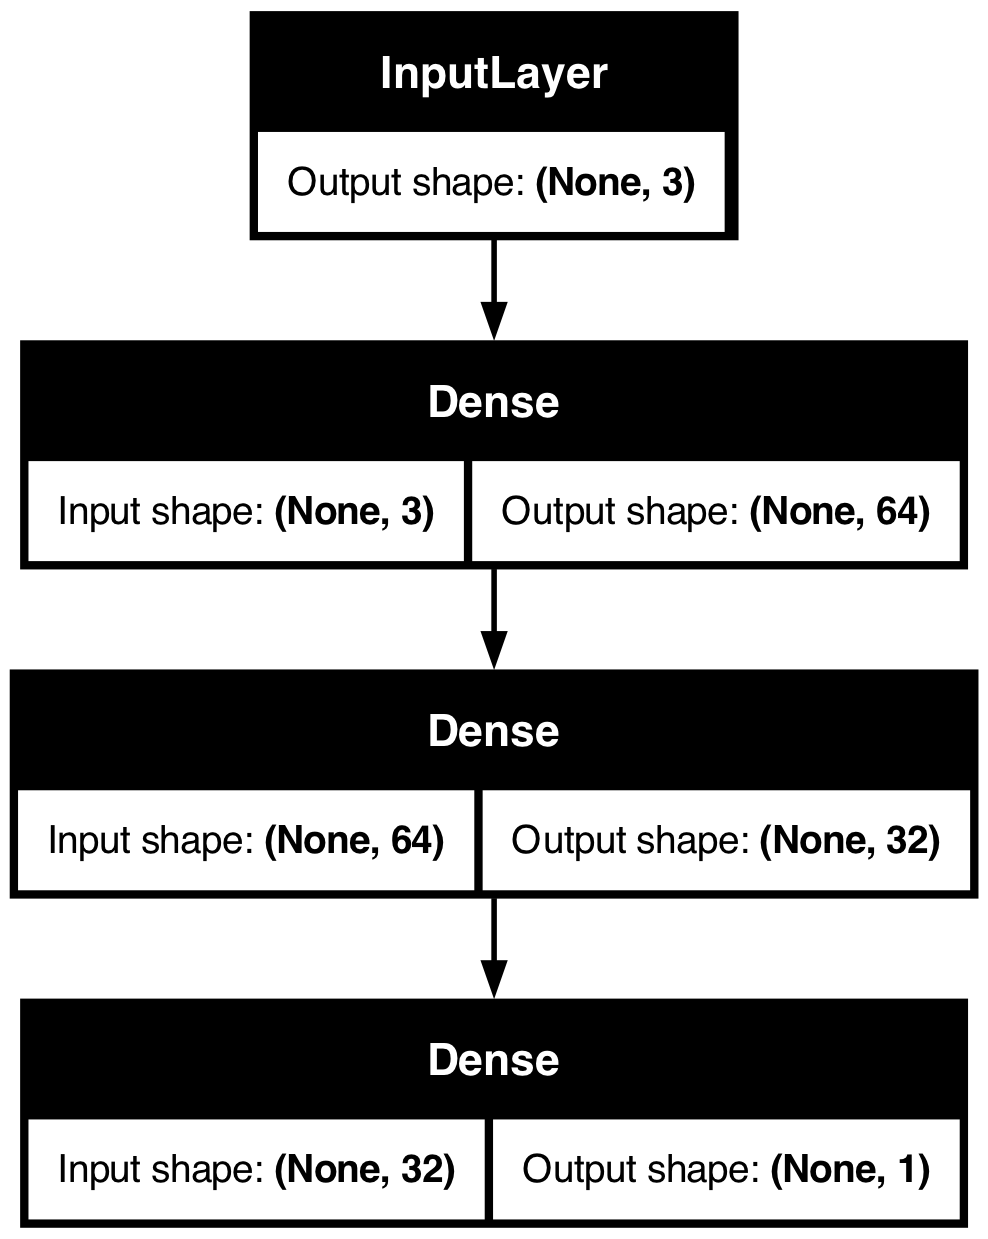

In [17]:
from keras.utils import plot_model
plot_model(model,show_shapes=True)